In [193]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn import metrics
%matplotlib inline

# Set some display settings.
sns.set(context='notebook')

# Setup

We started working with the Capital Bike Share dataset in Homework 2 and 4. In this exercise we will use *multiple features* and *feature engineering* to dramatically improve our prediction performance. But as we saw in Lab 5, these tools also run the risk of *overfitting*, so be careful...

As before, our basic goal will be to try to predict ridership in 2012 based on ridership data in 2011. So the 2011 data will be our *training set* and the 2012 data will be our *test set* (aka *held-out* data or sometimes *validation* data).

First, we'll load up the data.

In [194]:
hourly_counts_orig = pd.read_csv('data/hour.csv')
print(len(hourly_counts_orig), "observations")
hourly_counts_orig.head()

17379 observations


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Renaming
Some of those column names are pretty awful. Let's fix a few of them up.

In [196]:
hourly_counts = hourly_counts_orig.rename(columns={
    'dteday': 'date',
    'hr': "hour",
    'mnth': "month",
    'weekday': "day_of_week",
    'holiday': "is_holiday",
    'workingday': "is_workingday",

    'weathersit': "precip_type",
    "hum": "humidity",
    'cnt': "rides"
}).drop(["instant", "casual", "registered"], axis=1)
hourly_counts['day_of_year'] = pd.to_datetime(hourly_counts['date']).dt.dayofyear

# Rearrange the column order
hourly_counts = hourly_counts[['date', 'day_of_year', 'season', 'yr', 'day_of_week', 'month',
       'hour', 'is_holiday', 'is_workingday', 'precip_type', 'temp', 'atemp',
       'humidity', 'windspeed', 'rides']]
hourly_counts.head()

,date,day_of_year,season,yr,day_of_week,month,hour,is_holiday,is_workingday,precip_type,temp,atemp,humidity,windspeed,rides
0,2011-01-01,1,1,0,6,1,0,0,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,1,0,6,1,1,0,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,1,0,6,1,2,0,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,1,0,6,1,3,0,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,1,0,6,1,4,0,0,1,0.24,0.2879,0.75,0.0,1


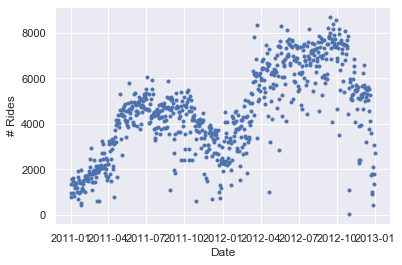

In [197]:
plt.plot(
    hourly_counts.groupby(
        pd.to_datetime(hourly_counts['date'])
    ).rides.sum(),
    '.')
plt.xlabel("Date")
plt.ylabel("# Rides");

# HACK!
Since the bike share program was overall more popular in 2012 than in 2011, predicting based on 2011 data will systematically under-predict ridership in 2012. More advanced modeling and validation techniques can handle this shift directly, but for now we'll do this little hack to make our current tools work. (Only do this in real life if you have a *really* good explanation for why, and be *totally* transparent about it if you do.)

First, we notice that there were many more rides in 2012 than in 2011.

In [186]:
hourly_counts.groupby('yr').rides.sum()

yr
0    1243103
1    2049576
Name: rides, dtype: int64

To make things comparable, let's normalize by popularity. Of course we wouldn't actually *know* the total popularity of 2012 during that year, which is why this particular approach is labeled "HACK!".

In [188]:
year_counts = hourly_counts.groupby('yr').rides.sum()
ratio = year_counts[1] / year_counts[0]
print("Scaling test set by", ratio)

hourly_counts['rides'] = np.where(hourly_counts.yr == 0, hourly_counts.rides, hourly_counts.rides / ratio)
print("New ridership totals by year:", hourly_counts.groupby('yr').rides.sum())

Scaling test set by 1.0000000000000007
New ridership totals by year: yr
0    1243103.0
1    1243103.0
Name: rides, dtype: float64


## Train-Test Split
We're going to use 2011 as the training set and 2012 as the test set.

In [138]:
train = hourly_counts[hourly_counts.yr == 0]
test = hourly_counts[hourly_counts.yr == 1]

In [139]:
assert train['date'].iloc[0] == '2011-01-01'
assert test['date'].iloc[0] == '2012-01-01'
assert all(train['date'].str.startswith('2011'))
assert all(test['date'].str.startswith('2012'))
assert len(train) + len(test) == len(hourly_counts)

In [140]:
train.drop(["yr"], axis=1).head()

,date,day_of_year,season,day_of_week,month,hour,is_holiday,is_workingday,precip_type,temp,atemp,humidity,windspeed,rides
0,2011-01-01,1,1,6,1,0,0,0,1,0.24,0.2879,0.81,0.0,16.0
1,2011-01-01,1,1,6,1,1,0,0,1,0.22,0.2727,0.80,0.0,40.0
2,2011-01-01,1,1,6,1,2,0,0,1,0.22,0.2727,0.80,0.0,32.0
3,2011-01-01,1,1,6,1,3,0,0,1,0.24,0.2879,0.75,0.0,13.0
4,2011-01-01,1,1,6,1,4,0,0,1,0.24,0.2879,0.75,0.0,1.0


# A Single Feature

Does apparent temperature ("feels like") affect ridership? Let's make a quick plot (we did this already last homework)

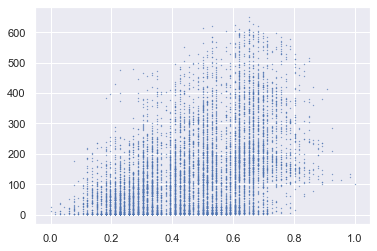

In [206]:
plt.scatter(train['atemp'], train['rides'], s=.1)

In [207]:
def transform(data):
    X = data[['atemp']]
    y = data['rides']
    return X, y
train_X, train_y = transform(train)
test_X, test_y = transform(test)

In [208]:
temp_only_model = LinearRegression().fit(train_X, train_y)

In [209]:
temp_only_model.coef_

array([338.37707325])

In [210]:
def show_scores(train_y, train_y_pred, test_y, test_y_pred):
    print("Training set MSE={:.2f}, r2={:.3f}".format(
        metrics.mean_squared_error(train_y, train_y_pred),
        metrics.r2_score(train_y, train_y_pred)
    ))
    print("Test set MSE={:.2f}, r2={:.3f}".format(
        metrics.mean_squared_error(test_y, test_y_pred),
        metrics.r2_score(test_y, test_y_pred)
    ))

train_y_pred = temp_only_model.predict(train_X)
test_y_pred = temp_only_model.predict(test_X)
    
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=14322.80, r2=0.200
Test set MSE=13604.77, r2=0.153


In [218]:
def show_coefficients(model, train_X):
    coefs_with_intercept = np.r_[[model.intercept_], model.coef_]
    feature_names_with_intercept = ["intercept"] + list(train_X.columns)
    display(
        pd.Series(coefs_with_intercept, index=feature_names_with_intercept)
        .to_frame('coefficient')
        .rename_axis(index="feature")
        .style.bar(align='mid'))

In [219]:
show_coefficients(temp_only_model, train_X)

,coefficient
feature,
intercept,-14.9046
atemp,338.377


## Add in `month` as a continuous feature

In [220]:
def transform(data):
    X = data[['atemp', 'month']]
    y = data['rides']
    return X, y
train_X, train_y = transform(train)
test_X, test_y = transform(test)

In [221]:
temp_and_month_model = LinearRegression().fit(train_X, train_y)

train_y_pred = temp_and_month_model.predict(train_X)
test_y_pred = temp_and_month_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)


Training set MSE=14259.13, r2=0.203
Test set MSE=13567.19, r2=0.155


In [222]:
show_coefficients(temp_and_month_model, train_X)

,coefficient
feature,
intercept,-24.8087
atemp,325.583
month,2.41935


Does `temp_and_month_model` predict better or worse than `temp_only_model`? How can you tell?

*answer*

For each of the following hypothetical kinds of relationships, can `temp_and_month_model` model them? Answer just *yes* or *no*:

* There were more rides in summer months than winter months
* The number of rides increased overall throughout the year.
* A 1-degree increase in temperature has a larger effect on ridership in winter months than in summer months.

True or fa

# One-hot encode `month`

Instead of using `month` as a continuous variable, let's use a one-hot encoding.

First, we notice that there are 12 unique values of `month`, as we'd expect:

In [227]:
months = sorted(set(train['month']))
months

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [246]:
def transform(data):
    X = data[['atemp']].copy()
    months_to_use = months[1:] # drop the first one, since it's redundant in this kind of model
    for month in months_to_use:
        X[f'month_{month}'] = 1.0 * (data['month'] == month)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)
train_X.head()

,atemp,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [247]:
temp_and_month_model = LinearRegression().fit(train_X, train_y)

train_y_pred = temp_and_month_model.predict(train_X)
test_y_pred = temp_and_month_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)
show_coefficients(temp_and_month_model, train_X)

Training set MSE=13795.07, r2=0.229
Test set MSE=13098.41, r2=0.184


,coefficient
feature,
intercept,-49.0975
atemp,513.378
month_2,-23.2985
month_3,-29.9554
month_4,-53.3761
month_5,-51.1229
month_6,-83.5096
month_7,-125.765
month_8,-100.507


Why would it have been redundant to include `month_1`?

*answer*

Does `temp_and_month_model` predict better or worse than `temp_only_model`? How can you tell?

*answer*

For each of the following hypothetical kinds of relationships, can `temp_and_month_model` (now with the one-hot encoding) model them? Answer just *yes* or *no*:

* There were more rides in summer months than winter months
* The number of rides increased overall throughout the year.
* A 1-degree increase in temperature has a larger effect on ridership in winter months than in summer months.

Does `temp_and_month_model` predict better or worse than `temp_only_model`? How can you tell?

*answer*

For each of the following hypothetical kinds of relationships, can `temp_and_month_model` model them? Answer just *yes* or *no*:

* There were more rides in summer months than winter months
* The number of rides increased overall throughout the year.
* A 1-degree increase in temperature has a larger effect on ridership in winter months than in summer months.

# If a column per month is better, how about one for each day?

Encouraged by the increase in performance we saw on both the training and test sets when we added a one-hot encoding for each month, let's try one-hot encoding each day.

In [241]:
dates = sorted(set(train['date']))

In [242]:
def transform(data):
    X = data[['atemp']].copy()
    dates_to_use = dates[1:] # drop the first one, since it's redundant.
    for date in dates_to_use:
        X[f'date_{date}'] = 1.0 * (data['date'] == date)
    return X

train_X = transform(train)
train_y = train['rides']
test_X = transform(test)
test_y = test['rides']
train_X.head()

,atemp,date_2011-01-02,date_2011-01-03,date_2011-01-04,date_2011-01-05,date_2011-01-06,date_2011-01-07,date_2011-01-08,date_2011-01-09,date_2011-01-10,...,date_2011-12-22,date_2011-12-23,date_2011-12-24,date_2011-12-25,date_2011-12-26,date_2011-12-27,date_2011-12-28,date_2011-12-29,date_2011-12-30,date_2011-12-31
0,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.2727,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.2879,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [243]:
train_X.shape

(8645, 365)

In [244]:
temp_and_date_model = LinearRegression().fit(train_X, train_y)
train_y_pred = temp_and_date_model.predict(train_X)
test_y_pred = temp_and_date_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=11268.52, r2=0.370
Test set MSE=30031.60, r2=-0.871


What happened? Why?

*answer*

# Your turn

Add a one-hot encoding for `hour`.

In [253]:
# your code here

Why did adding features for `month` and `hour` improve performance on the test set, while adding `date` did not?

*your answer here*

# One Hotter

When we did one-hot encoding, we arbitrarily picked 1.0 to be the value that would indicate the active month. What if we used 10.0 instead of 1.0? **Copy your code for `temp_and_month_model` to here** and **change the 1.0 to 10.0** for the indicator scale.

In [250]:
def transform(data):
    X = data[['atemp']].copy()
    months_to_use = months[1:] # drop the first one, since it's redundant in this kind of model
    for month in months_to_use:
        X[f'month_{month}'] = 10.0 * (data['month'] == month)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)
train_X.tail()

,atemp,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
8640,0.4242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
8641,0.4242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
8642,0.4091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
8643,0.3939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0
8644,0.3788,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0


In [251]:
temp_and_month_model = LinearRegression().fit(train_X, train_y)

train_y_pred = temp_and_month_model.predict(train_X)
test_y_pred = temp_and_month_model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)
show_coefficients(temp_and_month_model, train_X)

Training set MSE=13795.07, r2=0.229
Test set MSE=13098.41, r2=0.184


,coefficient
feature,
intercept,-49.0975
atemp,513.378
month_2,-2.32985
month_3,-2.99554
month_4,-5.33761
month_5,-5.11229
month_6,-8.35096
month_7,-12.5765
month_8,-10.0507


How does the **accuracy** of the 10.0 model on the training and test set compare with the 1.0 model?

*answer*

How do the **coefficients** of the 10.0 model compare with the coefficients of the 1.0 model?

*answer*

**True or False**: The larger the coefficient of a feature is, the more important that feature is to the model.

*answer*

# Convert temperature units
The `atemp` variable is in this weird "normalized" units. Could we get a better model by converting temperature to something more understandable, like degrees C?

According to the data page, `atemp` is:
```
	- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale) 
```

So to get back the temperature in degrees C, we'd use $atemp * (50 - (-16)) + (-16)$.

In [150]:
def transform(data):
    X = data[['atemp']].copy()
    X['atemp'] = X['atemp'] * (50 - (-16)) + (-16)
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=13795.07, r2=0.229
Test set MSE=13098.41, r2=0.184


How does the model performance compare with the previous `temp_and_month` model? Can you explain that observation?

*your answer here*

# Add a polynomial term for `atemp`

Since very hot temperatures may result in decreased ridership, let's permit the relationship between temperature and ridership to be non-linear. Let's add a simple nonlinearity: a 2nd-degree polynomial term (i.e., x^2).

In [252]:
def transform(data):
    X = data[['atemp']].copy()
    X['atemp^2'] = X['atemp'] ** 2
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)
show_coefficients(model, train_X)

Training set MSE=13578.16, r2=0.241
Test set MSE=12945.90, r2=0.194


,coefficient
feature,
intercept,29.487
atemp,-4.30884
atemp^2,565.828
month_2,-6.73094
month_3,-5.21522
month_4,-20.1132
month_5,-21.1443
month_6,-66.7199
month_7,-125.746


In [152]:
def transform(data):
    X = data.drop(['rides', 'date'], axis=1)
    X['atemp^2'] = X['atemp'] ** 2
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=10628.70, r2=0.406
Test set MSE=10568.30, r2=0.342


Your turn:

* Add a one-hot encoding for "hour".
* Pick one additional feature to add (see the `.head()` above for what the features are.

What effect does this have on the model?

In [163]:
def transform(data):
    X = data[['atemp', 'humidity']].copy()

    X['atemp^2'] = X['atemp'] ** 2
    X['humidity^2'] = X['humidity'] ** 2
    for hour in range(1, 24):
        X[f'hour_{hour}'] = (data['hour'] == hour).astype(float)
    
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=5772.76, r2=0.677
Test set MSE=5350.80, r2=0.667


Try using a KNeighborsRegressor instead of the LinearRegression. Note that you'll need to set a value for n_neighbors. What do you notice?

In [170]:
model  = KNeighborsRegressor(n_neighbors=30).fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=5097.75, r2=0.715
Test set MSE=5528.28, r2=0.656


Interaction between atemp and month

In [179]:
def transform(data):
    X = data[['atemp']].copy()#, 'humidity']].copy()

    X['atemp^2'] = X['atemp'] ** 2
    #X['humidity^2'] = X['humidity'] ** 2
    for hour in range(1, 24):
        X[f'hour_{hour}'] = (data['hour'] == hour).astype(float)
    
    months_to_use = months[1:] # drop the first one, since it's redundant.
    for month in months_to_use:
        X[f'month_{month}'] = (data['month'] == month).astype(float)
        #X[f'atemp*month_{month}'] = data['atemp'] * (data['month'] == month).astype(float)
    y = data['rides']
    return X, y

train_X, train_y = transform(train)
test_X, test_y = transform(test)

model  = LinearRegression().fit(train_X, train_y)
train_y_pred = model.predict(train_X)
test_y_pred = model.predict(test_X)
show_scores(train_y, train_y_pred, test_y, test_y_pred)

Training set MSE=6141.19, r2=0.657
Test set MSE=5500.47, r2=0.657


In [204]:
show_coefficients(model, train_X)

,coefficient
feature,
atemp,-13.1213
atemp^2,212.268
hour_1,-15.1931
hour_2,-23.0563
hour_3,-32.9608
hour_4,-37.9424
hour_5,-24.8695
hour_6,19.0616
hour_7,116.677
